# Wine Quality Kaggle

**Key considerations:**
- Target is ordinal (quality scores 3-8)
- QWK penalizes predictions far from true class more heavily
- Class imbalance requires stratified sampling
- Threshold optimization can significantly improve QWK

In [48]:
import numpy as np
import pandas as pd
import logging
from typing import Tuple, List, Optional

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import make_scorer, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
logging.basicConfig(level=logging.INFO)

pd.set_option('display.max_columns', None)

In [49]:
# Load data
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')
submission_df = pd.read_csv('sample_submission.csv')

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

Train shape: (15000, 13)
Test shape: (10000, 12)


Quality Distribution:
quality
3.0      95
4.0     450
5.0    6354
6.0    5993
7.0    1890
8.0     218
Name: count, dtype: int64

Quality range: 3.0 - 8.0
Number of classes: 6


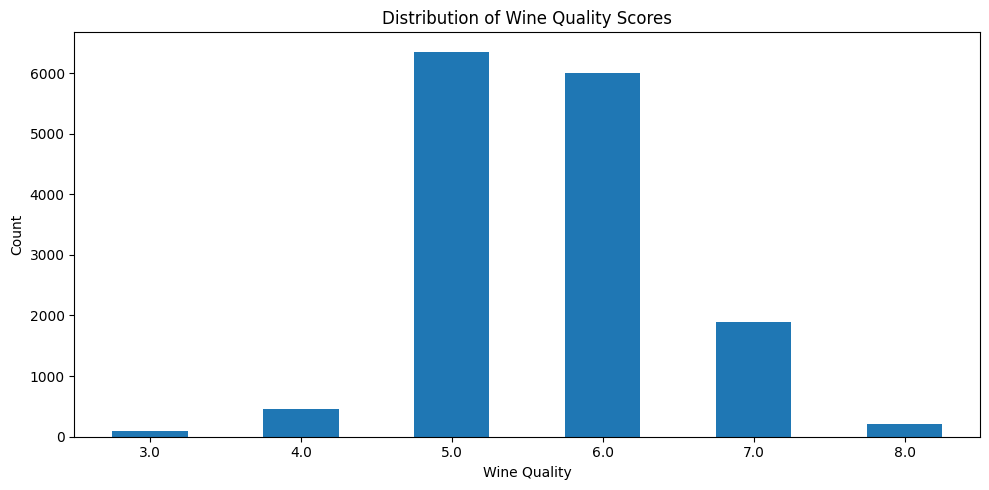

In [50]:
# Explore target distribution
print("Quality Distribution:")
print(train_df['quality'].value_counts().sort_index())
print(f"\nQuality range: {train_df['quality'].min()} - {train_df['quality'].max()}")
print(f"Number of classes: {train_df['quality'].nunique()}")

# Visualize target distribution
fig, ax = plt.subplots(figsize=(10, 5))
train_df['quality'].value_counts().sort_index().plot(kind='bar', ax=ax)
ax.set_xlabel('Wine Quality')
ax.set_ylabel('Count')
ax.set_title('Distribution of Wine Quality Scores')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [51]:
# Check for missing values
print("Missing values in train:")
print(train_df.isnull().sum())
print(f"\nMissing values in test:")
print(test_df.isnull().sum())

#no missing values, so we can skip imputation for now

Missing values in train:
id                      0
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Missing values in test:
id                      0
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
dtype: int64


In [52]:
# Data summary
train_df.describe()

,id,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7499.500000,8.150407,0.506026,0.229651,2.185944,0.078890,13.041077,36.893967,0.996907,3.323941,0.618216,10.183854,5.652467
std,4330.271354,1.389280,0.135077,0.178647,0.521511,0.014986,7.843052,23.956718,0.001392,0.116201,0.107910,0.900769,0.814861
min,0.000000,3.500000,0.180000,0.000000,1.100000,0.012000,0.650000,5.000000,0.990640,2.790000,0.400000,8.100000,3.000000
25%,3749.750000,7.200000,0.400000,0.050000,1.900000,0.073000,6.000000,19.000000,0.995880,3.240000,0.550000,9.500000,5.000000
50%,7499.500000,7.800000,0.510000,0.240000,2.100000,0.078000,11.000000,29.000000,0.996800,3.320000,0.590000,9.800000,6.000000
75%,11249.250000,8.900000,0.600000,0.370000,2.300000,0.084000,17.000000,48.000000,0.997800,3.390000,0.660000,10.800000,6.000000
max,14999.000000,15.800000,1.740000,0.770000,13.300000,0.415000,52.000000,152.000000,1.003690,4.010000,1.950000,15.000000,8.000000


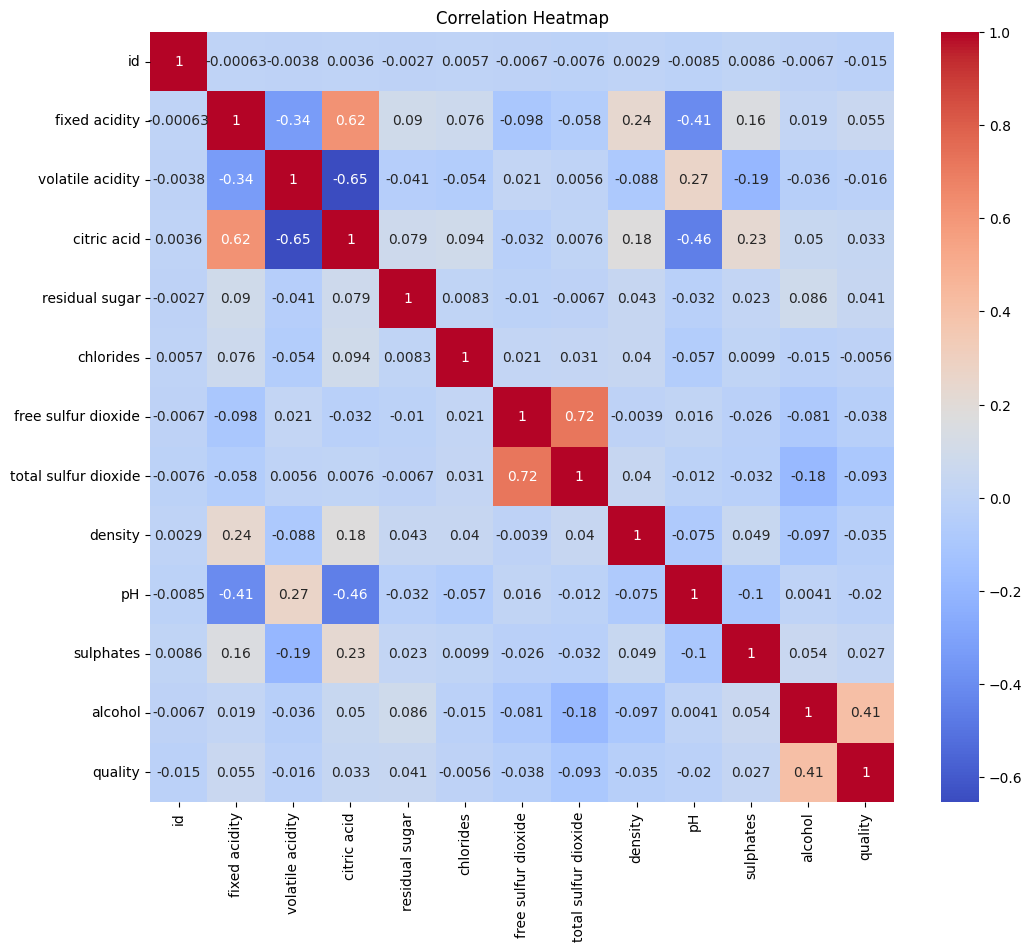

In [53]:
heatmap = train_df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(heatmap, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## Quadratic Weighted Kappa Implementation

In [54]:
def quadratic_weighted_kappa(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """
    Calculate Quadratic Weighted Kappa (QWK) between two arrays.
    
    QWK measures agreement between two raters, giving more weight to disagreements
    that are further apart on an ordinal scale.
    
    Parameters:
    -----------
    y_true : array-like
        Ground truth labels
    y_pred : array-like
        Predicted labels
        
    Returns:
    --------
    float : QWK score between -1 and 1 (1 = perfect agreement)
    """
    y_true = np.asarray(y_true).flatten()
    y_pred = np.asarray(y_pred).flatten()
    
    # Find the range of values
    min_rating = min(y_true.min(), y_pred.min())
    max_rating = max(y_true.max(), y_pred.max())
    
    # Ensure we have integer ratings
    y_true = np.round(y_true).astype(int)
    y_pred = np.round(y_pred).astype(int)
    
    # Number of possible rating values
    n_ratings = int(max_rating - min_rating + 1)
    
    # Build the observed histogram matrix O
    O = np.zeros((n_ratings, n_ratings))
    for actual, pred in zip(y_true, y_pred):
        O[int(actual - min_rating), int(pred - min_rating)] += 1
    
    # Build the weight matrix W (quadratic weights)
    W = np.zeros((n_ratings, n_ratings))
    for i in range(n_ratings):
        for j in range(n_ratings):
            W[i, j] = ((i - j) ** 2) / ((n_ratings - 1) ** 2)
    
    # Build the expected histogram matrix E
    actual_hist = np.sum(O, axis=1)
    pred_hist = np.sum(O, axis=0)
    E = np.outer(actual_hist, pred_hist)
    E = E / E.sum() * O.sum()
    
    # Calculate kappa
    numerator = np.sum(W * O)
    denominator = np.sum(W * E)
    
    if denominator == 0:
        return 0.0
    
    kappa = 1.0 - numerator / denominator
    return kappa


def qwk_scorer(y_true, y_pred):
    """Sklearn-compatible scorer (higher is better)."""
    return quadratic_weighted_kappa(y_true, y_pred)


# Create sklearn scorer
sklearn_qwk_scorer = make_scorer(qwk_scorer, greater_is_better=True)

# Test the implementation
test_actual = np.array([3, 4, 5, 6, 7, 8])
test_pred = np.array([3, 4, 5, 6, 7, 8])
print(f"Perfect prediction QWK: {quadratic_weighted_kappa(test_actual, test_pred):.4f}")

test_pred_off = np.array([4, 5, 6, 7, 8, 7])
print(f"Off-by-one predictions QWK: {quadratic_weighted_kappa(test_actual, test_pred_off):.4f}")

Perfect prediction QWK: 1.0000
Off-by-one predictions QWK: 0.8065


## Feature Engineering and Preprocessing

In [55]:
# Define feature columns
ID_COL = 'id'
TARGET_COL = 'quality'

FEATURE_COLS = [
    'fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
    'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
    'pH', 'sulphates', 'alcohol'
]

print(f"Number of features: {len(FEATURE_COLS)}")
print(f"Features: {FEATURE_COLS}")

Number of features: 11
Features: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


In [56]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    """
    Custom transformer to add engineered features as part of the pipeline.
    
    Wine chemistry domain-informed features:
    - Acidity ratios and interactions
    - Sulfur dioxide relationships
    - Bound sulfur dioxide
    - Alcohol-related ratios
    """
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = pd.DataFrame(X, columns=FEATURE_COLS) if not isinstance(X, pd.DataFrame) else X.copy()
        
        # Acidity features
        X['total_acidity'] = X['fixed acidity'] + X['volatile acidity']
        X['acidity_ratio'] = X['fixed acidity'] / (X['volatile acidity'] + 0.001)
        X['citric_to_fixed_acidity'] = X['citric acid'] / (X['fixed acidity'] + 0.001)
        
        # Sulfur dioxide features
        X['bound_sulfur_dioxide'] = X['total sulfur dioxide'] - X['free sulfur dioxide']
        X['free_sulfur_ratio'] = X['free sulfur dioxide'] / (X['total sulfur dioxide'] + 0.001)
        
        # Alcohol-density interaction
        X['alcohol_density_ratio'] = X['alcohol'] / (X['density'] + 0.001)
        
        # Sugar-alcohol balance
        X['sugar_alcohol_ratio'] = X['residual sugar'] / (X['alcohol'] + 0.001)
        
        # pH interactions
        X['ph_alcohol_interaction'] = X['pH'] * X['alcohol']
        X['ph_sulphates_interaction'] = X['pH'] * X['sulphates']
        
        # Chloride ratio
        X['chloride_density'] = X['chlorides'] * X['density']
        
        return X
    
    def get_feature_names_out(self, input_features=None):
        engineered = [
            'total_acidity', 'acidity_ratio', 'citric_to_fixed_acidity',
            'bound_sulfur_dioxide', 'free_sulfur_ratio', 'alcohol_density_ratio',
            'sugar_alcohol_ratio', 'ph_alcohol_interaction', 'ph_sulphates_interaction',
            'chloride_density'
        ]
        return FEATURE_COLS + engineered


# List of all features after engineering (for reference)
ALL_FEATURES = FeatureEngineer().get_feature_names_out()
print(f"Total features after engineering: {len(ALL_FEATURES)}")
print(f"Original features ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print(f"Engineered features ({len(ALL_FEATURES) - len(FEATURE_COLS)}): {ALL_FEATURES[len(FEATURE_COLS):]}")

Total features after engineering: 21
Original features (11): ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
Engineered features (10): ['total_acidity', 'acidity_ratio', 'citric_to_fixed_acidity', 'bound_sulfur_dioxide', 'free_sulfur_ratio', 'alcohol_density_ratio', 'sugar_alcohol_ratio', 'ph_alcohol_interaction', 'ph_sulphates_interaction', 'chloride_density']


## Threshold Optimization for QWK

For ordinal classification with QWK, we can train a regression model and then optimize the thresholds
for converting continuous predictions to discrete classes.

In [57]:
class ThresholdOptimizer:
    """
    Optimizes thresholds for converting continuous predictions to discrete classes,
    maximizing Quadratic Weighted Kappa.
    
    This is crucial for ordinal classification problems where the cost of errors
    increases with the distance from the true class.
    """
    
    def __init__(self, classes: List[int]):
        """
        Parameters:
        -----------
        classes : list
            Sorted list of possible class labels (e.g., [3, 4, 5, 6, 7, 8])
        """
        self.classes = sorted(classes)
        self.n_classes = len(classes)
        self.thresholds = None
        
    def _apply_thresholds(self, y_pred: np.ndarray, thresholds: np.ndarray) -> np.ndarray:
        """Convert continuous predictions to discrete classes using thresholds."""
        discrete_preds = np.zeros(len(y_pred), dtype=int)
        for i, pred in enumerate(y_pred):
            for j, threshold in enumerate(thresholds):
                if pred < threshold:
                    discrete_preds[i] = self.classes[j]
                    break
            else:
                discrete_preds[i] = self.classes[-1]
        return discrete_preds
    
    def _objective(self, thresholds: np.ndarray, y_true: np.ndarray, y_pred: np.ndarray) -> float:
        """Objective function: negative QWK (for minimization)."""
        # Ensure thresholds are sorted
        thresholds = np.sort(thresholds)
        discrete_preds = self._apply_thresholds(y_pred, thresholds)
        return -quadratic_weighted_kappa(y_true, discrete_preds)
    
    def fit(self, y_true: np.ndarray, y_pred: np.ndarray) -> 'ThresholdOptimizer':
        """
        Find optimal thresholds that maximize QWK.
        
        Parameters:
        -----------
        y_true : array-like
            True class labels
        y_pred : array-like
            Continuous predictions from regression model
        """
        # Initialize thresholds at class boundaries
        initial_thresholds = np.array([c + 0.5 for c in self.classes[:-1]])
        
        # Optimize using Nelder-Mead
        result = minimize(
            self._objective,
            initial_thresholds,
            args=(y_true, y_pred),
            method='Nelder-Mead',
            options={'maxiter': 1000, 'xatol': 0.001}
        )
        
        self.thresholds = np.sort(result.x)
        return self
    
    def predict(self, y_pred: np.ndarray) -> np.ndarray:
        """Apply optimized thresholds to convert predictions to classes."""
        if self.thresholds is None:
            raise ValueError("ThresholdOptimizer must be fit before predict")
        return self._apply_thresholds(y_pred, self.thresholds)
    
    def get_thresholds(self) -> np.ndarray:
        """Return the optimized thresholds."""
        return self.thresholds


# Test the threshold optimizer
print("Threshold optimizer defined successfully")

Threshold optimizer defined successfully


## Model Pipeline

In [58]:
def get_model() -> HistGradientBoostingRegressor:
    """
    Create HistGradientBoostingRegressor configured for ordinal regression.
    
    Uses squared_error loss as we'll optimize thresholds post-hoc for QWK.
    """
    return HistGradientBoostingRegressor(
        loss='squared_error',
        learning_rate=0.05,
        max_iter=500,
        max_depth=6,
        min_samples_leaf=20,
        l2_regularization=1.0,
        random_state=42,
    )


def get_model_pipeline() -> Pipeline:
    """Create full model pipeline with feature engineering, preprocessing, and model."""
    return Pipeline([
        ('feature_engineer', FeatureEngineer()),
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', RobustScaler()),
        ('model', get_model())
    ])


print("Model pipeline functions defined successfully")

Model pipeline functions defined successfully


## Cross-Validation Training with Threshold Optimization

In [59]:
def train_with_cv(
    X: pd.DataFrame,
    y: pd.Series,
    n_folds: int = 5,
    random_state: int = 42
) -> Tuple[np.ndarray, List[Pipeline], ThresholdOptimizer]:
    """
    Train model with stratified k-fold cross-validation and threshold optimization.
    
    Parameters:
    -----------
    X : DataFrame
        Feature matrix (original features - engineering done in pipeline)
    y : Series
        Target variable
    n_folds : int
        Number of CV folds
    random_state : int
        Random seed for reproducibility
        
    Returns:
    --------
    oof_preds : array
        Out-of-fold predictions (continuous)
    models : list
        List of trained pipeline objects
    threshold_optimizer : ThresholdOptimizer
        Fitted threshold optimizer
    """
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=random_state)
    
    oof_preds = np.zeros(len(X))
    models = []
    fold_scores = []
    
    # Get unique classes for threshold optimization
    classes = sorted(y.unique().astype(int).tolist())
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
        y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]
        
        # Create and train model pipeline
        pipeline = get_model_pipeline()
        pipeline.fit(X_train_fold, y_train_fold)
        
        # Get predictions
        val_preds = pipeline.predict(X_val_fold)
        oof_preds[val_idx] = val_preds
        
        # Calculate fold score with simple rounding
        simple_preds = np.clip(np.round(val_preds), min(classes), max(classes)).astype(int)
        fold_qwk = quadratic_weighted_kappa(y_val_fold, simple_preds)
        fold_scores.append(fold_qwk)
        
        models.append(pipeline)
        logging.info(f"Fold {fold + 1} - QWK (simple rounding): {fold_qwk:.4f}")
    
    # Calculate overall OOF score with simple rounding
    simple_oof_preds = np.clip(np.round(oof_preds), min(classes), max(classes)).astype(int)
    oof_qwk_simple = quadratic_weighted_kappa(y, simple_oof_preds)
    
    # Optimize thresholds on OOF predictions
    threshold_optimizer = ThresholdOptimizer(classes)
    threshold_optimizer.fit(y.values, oof_preds)
    
    # Calculate OOF score with optimized thresholds
    optimized_oof_preds = threshold_optimizer.predict(oof_preds)
    oof_qwk_optimized = quadratic_weighted_kappa(y, optimized_oof_preds)
    
    logging.info(f"\n{'='*50}")
    logging.info(f"Mean CV QWK (simple rounding): {np.mean(fold_scores):.4f} +/- {np.std(fold_scores):.4f}")
    logging.info(f"OOF QWK (simple rounding): {oof_qwk_simple:.4f}")
    logging.info(f"OOF QWK (optimized thresholds): {oof_qwk_optimized:.4f}")
    logging.info(f"Improvement from threshold optimization: {oof_qwk_optimized - oof_qwk_simple:.4f}")
    logging.info(f"Optimized thresholds: {threshold_optimizer.get_thresholds()}")
    
    return oof_preds, models, threshold_optimizer


print("Cross-validation training function defined successfully")

Cross-validation training function defined successfully


In [60]:
from sklearn.model_selection import train_test_split

# Prepare data for training (use original features - engineering happens in pipeline)
X = train_df[FEATURE_COLS]
y = train_df[TARGET_COL]

# Split into train and holdout test set
X_train, X_holdout, y_train, y_holdout = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Full dataset shape: {X.shape}")
print(f"Training set shape: {X_train.shape}")
print(f"Holdout set shape: {X_holdout.shape}")
print(f"\nInput features: {FEATURE_COLS}")
print(f"Engineered features (added in pipeline): {ALL_FEATURES[len(FEATURE_COLS):]}")
print(f"\nTarget distribution in training set:\n{y_train.value_counts().sort_index()}")

Full dataset shape: (15000, 11)
Training set shape: (12000, 11)
Holdout set shape: (3000, 11)

Input features: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
Engineered features (added in pipeline): ['total_acidity', 'acidity_ratio', 'citric_to_fixed_acidity', 'bound_sulfur_dioxide', 'free_sulfur_ratio', 'alcohol_density_ratio', 'sugar_alcohol_ratio', 'ph_alcohol_interaction', 'ph_sulphates_interaction', 'chloride_density']

Target distribution in training set:
quality
3.0      76
4.0     360
5.0    5083
6.0    4795
7.0    1512
8.0     174
Name: count, dtype: int64


In [61]:
# Train model with cross-validation on training set
oof_preds, models, threshold_optimizer = train_with_cv(
    X=X_train,
    y=y_train,
    n_folds=5,
    random_state=42
)

# Evaluate on holdout set
holdout_preds_continuous = np.mean([m.predict(X_holdout) for m in models], axis=0)
holdout_preds = threshold_optimizer.predict(holdout_preds_continuous)
holdout_qwk = quadratic_weighted_kappa(y_holdout, holdout_preds)

print(f"\n{'='*50}")
print(f"HOLDOUT SET PERFORMANCE")
print(f"{'='*50}")
print(f"Holdout QWK: {holdout_qwk:.4f}")

INFO:root:Fold 1 - QWK (simple rounding): 0.3103
INFO:root:Fold 2 - QWK (simple rounding): 0.3191
INFO:root:Fold 3 - QWK (simple rounding): 0.3172
INFO:root:Fold 4 - QWK (simple rounding): 0.2543
INFO:root:Fold 5 - QWK (simple rounding): 0.3054
INFO:root:
INFO:root:Mean CV QWK (simple rounding): 0.3013 +/- 0.0240
INFO:root:OOF QWK (simple rounding): 0.3014
INFO:root:OOF QWK (optimized thresholds): 0.3910
INFO:root:Improvement from threshold optimization: 0.0896
INFO:root:Optimized thresholds: [3.58815919 4.53232389 5.6545298  5.96593927 7.72113433]



HOLDOUT SET PERFORMANCE
Holdout QWK: 0.4073


## Model Evaluation and Visualization

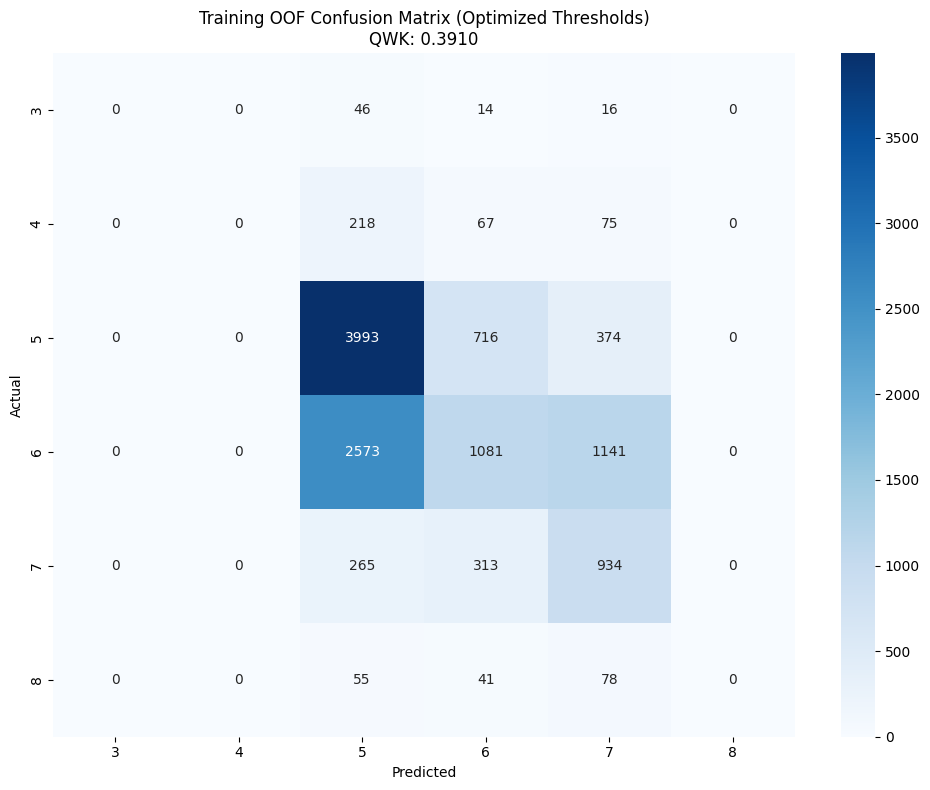

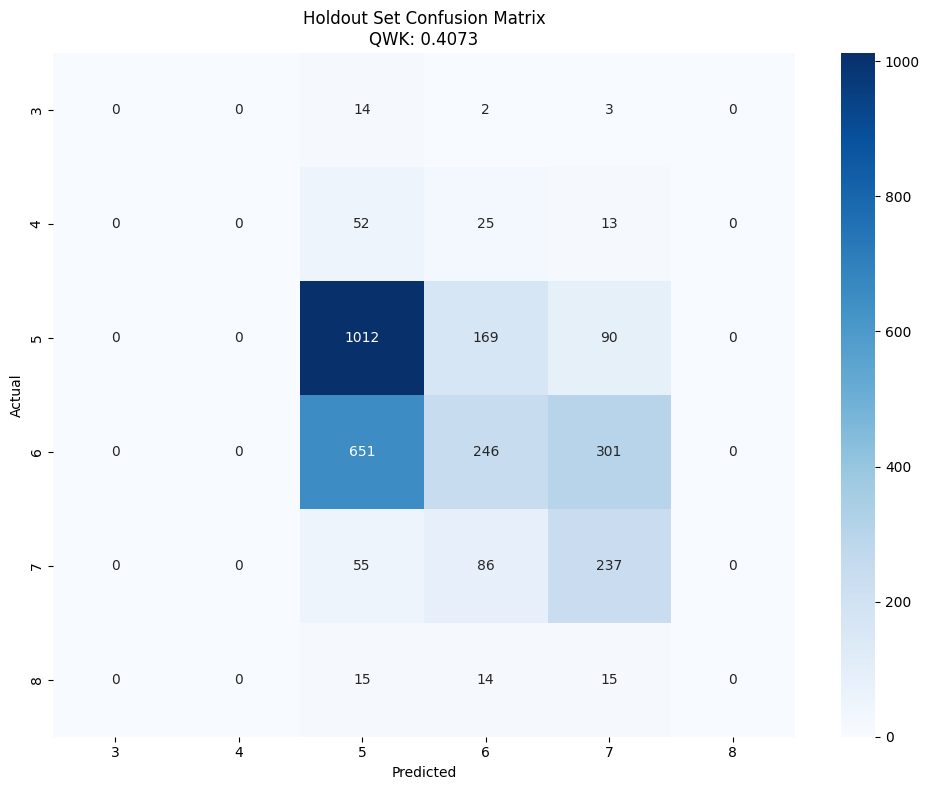

In [62]:
def plot_confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray, title: str = "Confusion Matrix"):
    """Plot confusion matrix heatmap."""
    classes = sorted(set(y_true) | set(y_pred))
    cm = confusion_matrix(y_true, y_pred, labels=classes)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'{title}\nQWK: {quadratic_weighted_kappa(y_true, y_pred):.4f}')
    plt.tight_layout()
    plt.show()
    
    return cm


# Plot confusion matrix for OOF predictions (training set)
optimized_preds = threshold_optimizer.predict(oof_preds)
cm_train = plot_confusion_matrix(y_train.values.astype(int), optimized_preds, 
                                  title="Training OOF Confusion Matrix (Optimized Thresholds)")

# Plot confusion matrix for holdout set
cm_holdout = plot_confusion_matrix(y_holdout.values.astype(int), holdout_preds,
                                    title="Holdout Set Confusion Matrix")

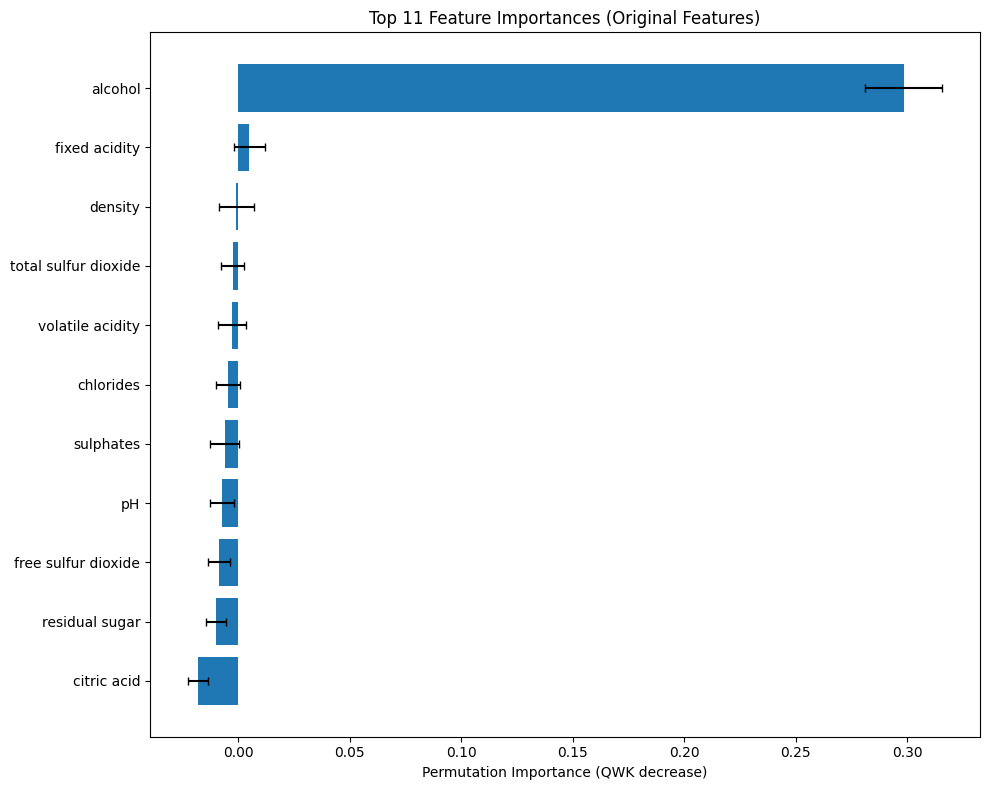

In [63]:
from sklearn.inspection import permutation_importance

def plot_feature_importance(models: List[Pipeline], X_val, y_val, top_n: int = 15):
    """Plot permutation feature importance using validation data."""
    # Permutation importance works on input features (before pipeline transforms them)
    result = permutation_importance(
        models[0], X_val, y_val, 
        n_repeats=10, 
        random_state=42,
        scoring=make_scorer(qwk_scorer)
    )
    
    # Create dataframe for plotting (use input feature names)
    importance_df = pd.DataFrame({
        'feature': FEATURE_COLS,
        'importance': result.importances_mean,
        'std': result.importances_std
    }).sort_values('importance', ascending=True).tail(top_n)
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(importance_df['feature'], importance_df['importance'], 
            xerr=importance_df['std'], capsize=3)
    ax.set_xlabel('Permutation Importance (QWK decrease)')
    ax.set_title(f'Top {top_n} Feature Importances (Original Features)')
    plt.tight_layout()
    plt.show()
    
    return importance_df


importance_df = plot_feature_importance(models, X_holdout, y_holdout, top_n=11)

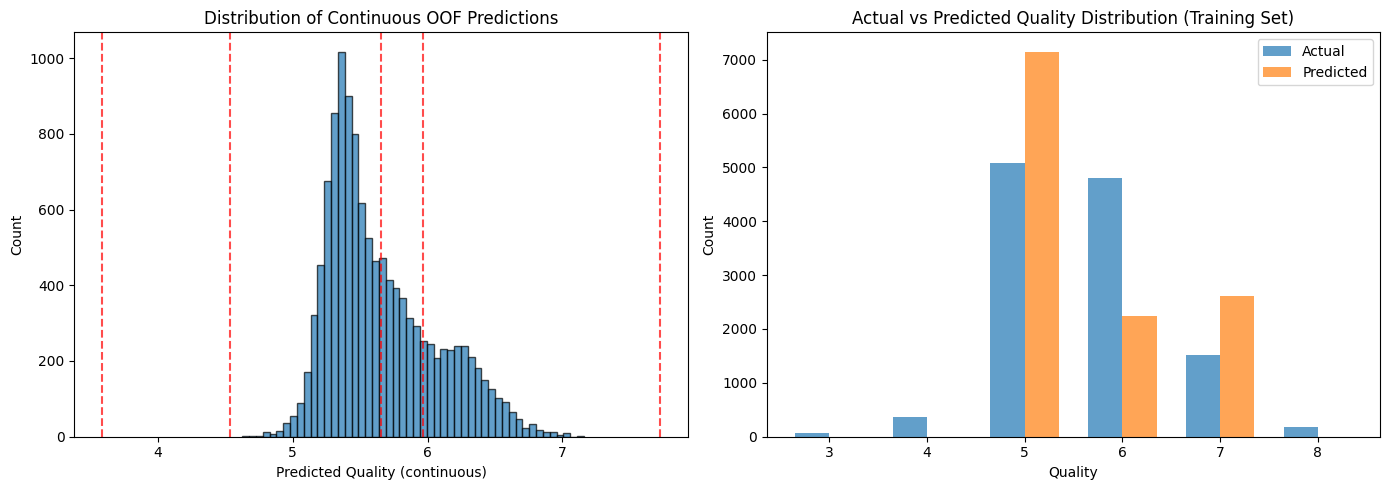

In [64]:
# Analyze prediction distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Continuous predictions distribution
axes[0].hist(oof_preds, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Predicted Quality (continuous)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Continuous OOF Predictions')

# Show thresholds
thresholds = threshold_optimizer.get_thresholds()
for t in thresholds:
    axes[0].axvline(x=t, color='red', linestyle='--', alpha=0.7)

# Discrete predictions vs actual (training set)
pred_counts = pd.Series(optimized_preds).value_counts().sort_index()
actual_counts = y_train.value_counts().sort_index()

x = np.arange(len(actual_counts))
width = 0.35
axes[1].bar(x - width/2, actual_counts.values, width, label='Actual', alpha=0.7)
axes[1].bar(x + width/2, pred_counts.reindex(actual_counts.index, fill_value=0).values, 
            width, label='Predicted', alpha=0.7)
axes[1].set_xlabel('Quality')
axes[1].set_ylabel('Count')
axes[1].set_xticks(x)
axes[1].set_xticklabels(actual_counts.index.astype(int))
axes[1].legend()
axes[1].set_title('Actual vs Predicted Quality Distribution (Training Set)')

plt.tight_layout()
plt.show()

## Generate Submission

In [65]:
def generate_predictions(
    models: List[Pipeline],
    X_test: pd.DataFrame,
    threshold_optimizer: ThresholdOptimizer
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Generate predictions on test data using ensemble of CV models.
    
    Parameters:
    -----------
    models : list
        List of trained pipeline objects from CV
    X_test : DataFrame
        Test feature matrix (original features - engineering done in pipeline)
    threshold_optimizer : ThresholdOptimizer
        Fitted threshold optimizer
        
    Returns:
    --------
    predictions : array
        Discrete class predictions
    continuous_preds : array
        Continuous predictions before thresholding
    """
    # Get predictions from all models
    all_preds = np.zeros((len(X_test), len(models)))
    for i, model in enumerate(models):
        all_preds[:, i] = model.predict(X_test)
    
    # Average predictions
    avg_preds = np.mean(all_preds, axis=1)
    
    # Apply optimized thresholds
    discrete_preds = threshold_optimizer.predict(avg_preds)
    
    return discrete_preds, avg_preds


# Generate test predictions (use original features - engineering in pipeline)
X_test = test_df[FEATURE_COLS]
test_predictions, test_continuous_preds = generate_predictions(models, X_test, threshold_optimizer)

print(f"Test predictions shape: {test_predictions.shape}")
print(f"Test prediction distribution:\n{pd.Series(test_predictions).value_counts().sort_index()}")

Test predictions shape: (10000,)
Test prediction distribution:
5    5916
6    1919
7    2165
Name: count, dtype: int64


In [66]:
# Create submission file
submission = pd.DataFrame({
    'id': test_df['id'],
    'quality': test_predictions
})

# Verify submission format
print("Submission preview:")
print(submission.head(10))
print(f"\nSubmission shape: {submission.shape}")
print(f"\nSubmission quality distribution:\n{submission['quality'].value_counts().sort_index()}")

Submission preview:
      id  quality
0  15000        5
1  15001        7
2  15002        5
3  15003        7
4  15004        6
5  15005        5
6  15006        7
7  15007        6
8  15008        5
9  15009        5

Submission shape: (10000, 2)

Submission quality distribution:
quality
5    5916
6    1919
7    2165
Name: count, dtype: int64


In [67]:
# Save submission
submission.to_csv('submission.csv', index=False)
print("Submission saved to 'submission.csv'")

Submission saved to 'submission.csv'
